# Get a model report

The report includes: 
- Accuracy, Precision, Recall, F1 Score, Specificity, ROC-AUC, Matriz de confusion
- Graphs of train acc (%), train err (%), test acc (%) test err (%)

In [18]:
# pip install scikit-learn
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

MODEL_PATH = Path("models/cnn_propia_02.keras")

## Config

In [19]:
IMG_SIZE = 256
BATCH_SIZE = 8
LABEL_MODE = "binary"
CLASS_NAMES = ["no", "yes"]
TEST_DIR = Path("data/dataset_ready/test")

# Change this path when evaluating a different saved model.
REPORT_DIR = Path("reports") / MODEL_PATH.stem
REPORT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_CSV_PATH = REPORT_DIR / "test_metrics.csv"
CLASSIFICATION_REPORT_CSV_PATH = REPORT_DIR / "classification_report.csv"
CONFUSION_MATRIX_CSV_PATH = REPORT_DIR / "confusion_matrix.csv"
CONFUSION_MATRIX_PNG_PATH = REPORT_DIR / "confusion_matrix.png"

## Load

In [20]:
loaded_model = load_model(MODEL_PATH)
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,609,205 (6.14 MB)

 Trainable params: 536,401 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,072,804 (4.09 MB)

In [21]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=False # Solo en test queremos evitar el shuffle, para debuggear mejor.
)

Found 51 files belonging to 2 classes.


## Test Metrics

In [22]:
# Predicciones del modelo
probs = loaded_model.predict(test_ds).ravel()

# Convertir probabilidades a clases binarias
y_pred = (probs > 0.5).astype(int)

# Etiquetas reales
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
]).ravel().astype(int)

# Metricas
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
roc_auc = roc_auc_score(y_true, probs)

metrics = [
    ("Accuracy", accuracy_score(y_true, y_pred)),
    ("Precision", precision_score(y_true, y_pred, zero_division=0)),
    ("Recall", recall_score(y_true, y_pred, zero_division=0)),
    ("F1 Score", f1_score(y_true, y_pred, zero_division=0)),
    ("Specificity", specificity),
    ("ROC-AUC", roc_auc),
]

for metric_name, metric_value in metrics:
    print(f"{metric_name:<12}: {metric_value}")

with METRICS_CSV_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["metric", "value"])
    writer.writerows(metrics)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

with CLASSIFICATION_REPORT_CSV_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    fieldnames = ["label", "precision", "recall", "f1-score", "support"]
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for label, values in report_dict.items():
        if isinstance(values, dict):
            writer.writerow({"label": label, **values})
        else:
            writer.writerow({
                "label": label,
                "precision": "",
                "recall": "",
                "f1-score": values,
                "support": len(y_true)
            })

print(f"\nSaved metrics CSV to: {METRICS_CSV_PATH}")
print(f"Saved classification report CSV to: {CLASSIFICATION_REPORT_CSV_PATH}")

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/stepWARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002A7C15FFC40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Accuracy    : 0.6078431372549019
Precision   : 0.6078431372549019
Recall      : 1.0
F1 Score    : 0.7560975609756098
Specificity : 0.0
ROC-AUC     : 0.5370967741935484

Saved metrics CSV to: reports

## Confusion Matrix

|               | Predicho Negativo | Predicho Positivo |
| ------------- | ----------------- | ----------------- |
| Real Negativo | VN           | FP            |
| Real Positivo | FN        | VP          |

Saved confusion matrix plot to: reports\cnn_propia_02\confusion_matrix.png


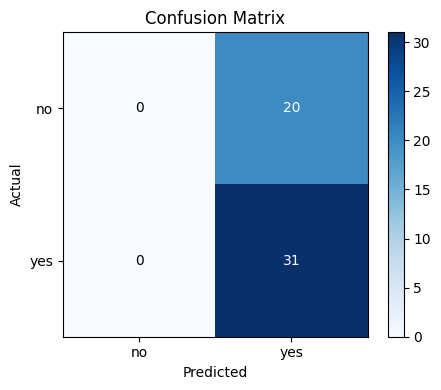

In [23]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

threshold = cm.max() / 2
for row_idx in range(cm.shape[0]):
    for col_idx in range(cm.shape[1]):
        ax.text(
            col_idx,
            row_idx,
            cm[row_idx, col_idx],
            ha="center",
            va="center",
            color="white" if cm[row_idx, col_idx] > threshold else "black"
        )

fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PNG_PATH, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix plot to: {CONFUSION_MATRIX_PNG_PATH}")
plt.show()

## Single Image Inference (loaded model)

In [24]:
from tensorflow.keras.preprocessing import image

img_path = Path("data/dataset_ready/test/yes/images_yes_005.png")

if not img_path.exists():
    raise FileNotFoundError(f"Image file not found: {img_path}")

img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

prob = loaded_model.predict(x, verbose=0)[0][0]

print("Tumor probability:", prob)

if prob > 0.5:
    print("Prediction: YES (Tumor)")
else:
    print("Prediction: NO (Healthy)")

Tumor probability: 0.7488853
Prediction: YES (Tumor)
